# Pythagorean Expectation for the NFL
Baseball has a famous formula that guesses a team's win % from runs scored and runs allowed. Does the same idea work in the NFL?

**win % = PF^k / (PF^k + PA^k)**  (PF = points for, PA = points against, k = a number we fit)

Steps: 1) build the data, 2) fit k, 3) test it on later seasons, 4) plot it, 5) look at lucky/unlucky teams, 6) use it for playoff odds this season.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import nfl_data_py as nfl

## 1. Data
One row per team per season: points for, points against, wins, games played.

In [2]:
# every regular season game since 1999
games = nfl.import_schedules(range(1999, 2026))
games = games[games.game_type == "REG"].dropna(subset=["home_score", "away_score"])

# each game becomes two rows, one from each team's point of view
home = games.assign(team=games.home_team, pf=games.home_score, pa=games.away_score)
away = games.assign(team=games.away_team, pf=games.away_score, pa=games.home_score)
long = pd.concat([home, away])[["season", "team", "pf", "pa"]].copy()

long["w"] = (long.pf > long.pa) + 0.5 * (long.pf == long.pa)   # a tie counts as half a win
long["gp"] = 1

# add everything up by team and season
t = long.groupby(["season", "team"], as_index=False)[["pf", "pa", "w", "gp"]].sum()
t["wpct"] = t.w / t.gp
t["x"] = np.log(t.pf / t.pa)     # this is the input for the regression, see next section
print(len(games), "games ->", len(t), "team-seasons")
t.head()

6967 games -> 861 team-seasons


,season,team,pf,pa,w,gp,wpct,x
0,1999,ARI,245.0,382.0,6.0,16,0.3750,-0.444162
1,1999,ATL,285.0,380.0,5.0,16,0.3125,-0.287682
2,1999,BAL,324.0,277.0,8.0,16,0.5000,0.156726
3,1999,BUF,320.0,229.0,11.0,16,0.6875,0.334599
4,1999,CAR,421.0,381.0,8.0,16,0.5000,0.099833


## 2. Fit k
If you take logs, the formula turns into a straight line: **logit(win %) = k * log(PF / PA)**.
So k is just the slope, and I can get it with a logistic regression (weighting each team by games played).

In [3]:
def fit(df, intercept=False):
    X = sm.add_constant(df[["x"]]) if intercept else df[["x"]]
    return sm.GLM(df.wpct, X, family=sm.families.Binomial(), freq_weights=df.gp).fit()

m0 = fit(t)                    # no intercept
m1 = fit(t, intercept=True)    # with intercept, just to check we don't need it
print(m0.summary().tables[1])
print(m1.summary().tables[1])
K = m0.params["x"]
print(f"k = {K:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x              2.6657      0.069     38.798      0.000       2.531       2.800
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0128      0.018      0.709      0.478      -0.023       0.048
x              2.6661      0.069     38.809      0.000       2.531       2.801
k = 2.666


The intercept is basically 0 and not significant, so a team that scores as much as it allows really is a .500 team here. Next, how sure am I about k? Resample the team-seasons a bunch of times and refit.

In [4]:
rng = np.random.default_rng(0)
ks = []
for _ in range(500):
    resample = t.sample(len(t), replace=True, random_state=int(rng.integers(1e9)))
    ks.append(fit(resample).params["x"])

lo, hi = np.percentile(ks, [2.5, 97.5])
print(f"k = {K:.3f}, 95% range [{lo:.3f}, {hi:.3f}]  (the number people usually quote for the NFL is 2.37)")

k = 2.666, 95% range [2.568, 2.767]  (the number people usually quote for the NFL is 2.37)


## 3. Does it work on seasons it hasn't seen?
Fit on 1999-2019, then predict 2020-2025 and see how many wins off it is per team.

In [5]:
train = t[t.season <= 2019]
test = t[t.season >= 2020]
k_train = fit(train).params["x"]

def expected_wins(df, k):
    return df.gp * df.pf**k / (df.pf**k + df.pa**k)

def miss(pred, actual):
    err = pred - actual
    return pd.Series({"avg miss (wins)": err.abs().mean(), "RMSE": np.sqrt((err**2).mean())})

pd.DataFrame({
    f"my k = {k_train:.2f}": miss(expected_wins(test, k_train), test.w),
    "k = 2.37": miss(expected_wins(test, 2.37), test.w),
    "k = 1.83 (baseball)": miss(expected_wins(test, 1.83), test.w),
    "everyone at .500": miss(test.gp / 2, test.w),
}).T.round(3)

,avg miss (wins),RMSE
my k = 2.62,1.111,1.411
k = 2.37,1.158,1.458
k = 1.83 (baseball),1.357,1.673
everyone at .500,2.656,3.193


## 4. Plots

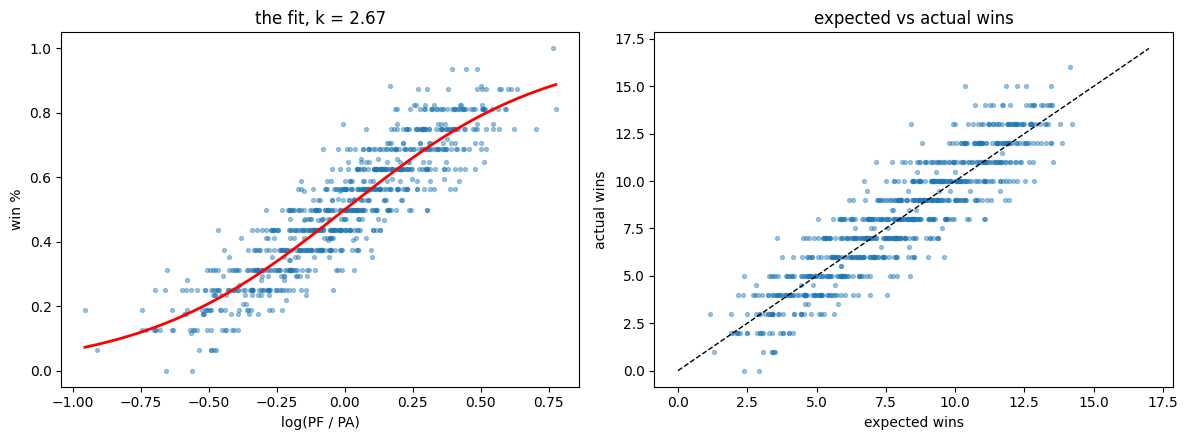

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

xs = np.linspace(t.x.min(), t.x.max(), 200)
ax[0].scatter(t.x, t.wpct, s=8, alpha=0.4)
ax[0].plot(xs, 1 / (1 + np.exp(-K * xs)), "r", lw=2)
ax[0].set(xlabel="log(PF / PA)", ylabel="win %", title=f"the fit, k = {K:.2f}")

t["exp_w"] = expected_wins(t, K)
ax[1].scatter(t.exp_w, t.w, s=8, alpha=0.4)
ax[1].plot([0, 17], [0, 17], "k--", lw=1)
ax[1].set(xlabel="expected wins", ylabel="actual wins", title="expected vs actual wins")

plt.tight_layout()
plt.show()

## 5. Lucky and unlucky teams
Actual wins minus expected wins. Big positives are teams that won more than their points say they should have.

In [7]:
t["diff"] = t.w - t.exp_w
cols = ["season", "team", "pf", "pa", "w", "exp_w", "diff"]
print("luckiest")
display(t.sort_values("diff", ascending=False)[cols].head(10).round(2))
print("unluckiest")
display(t.sort_values("diff")[cols].head(10).round(2))

luckiest


,season,team,pf,pa,w,exp_w,diff
812,2024,KC,385.0,326.0,15.0,10.35,4.65
753,2022,MIN,424.0,427.0,13.0,8.42,4.58
426,2012,IND,357.0,387.0,11.0,7.14,3.86
396,2011,KC,212.0,338.0,7.0,3.58,3.42
719,2021,LV,374.0,439.0,10.0,6.71,3.29
676,2020,CLE,408.0,419.0,11.0,7.72,3.28
684,2020,KC,473.0,362.0,14.0,10.74,3.26
564,2016,OAK,416.0,385.0,12.0,8.82,3.18
181,2004,PIT,372.0,251.0,15.0,11.85,3.15
648,2019,GB,376.0,313.0,13.0,9.92,3.08


unluckiest


,season,team,pf,pa,w,exp_w,diff
844,2025,KC,362.0,328.0,6.0,9.61,-3.61
670,2020,ATL,396.0,414.0,4.0,7.53,-3.53
86,2001,SD,332.0,321.0,5.0,8.36,-3.36
235,2006,JAX,371.0,274.0,8.0,11.07,-3.07
645,2019,DAL,434.0,321.0,8.0,11.05,-3.05
296,2008,GB,419.0,380.0,6.0,9.04,-3.04
319,2009,BAL,391.0,261.0,9.0,11.94,-2.94
580,2017,CLE,234.0,410.0,0.0,2.93,-2.93
852,2025,NYG,381.0,439.0,4.0,6.91,-2.91
186,2004,TB,301.0,304.0,5.0,7.89,-2.89


Does the luck carry over? If it were skill, a team that beat its expected wins this year would do it again next year.

In [8]:
nxt = t[["season", "team", "diff"]].copy()
nxt["season"] -= 1                       # line up each season with the one after it
both = t.merge(nxt, on=["season", "team"], suffixes=("", "_next"))
print("correlation of this year's luck with next year's:", round(both["diff"].corr(both["diff_next"]), 3))

correlation of this year's luck with next year's: 0.003


## 6. Playoff odds for this season
Plan: get a rating for every team from its points so far, turn ratings into a win chance for every remaining game, play the rest of the season out 10,000 times, and see who makes the playoffs in each one.

- **Rating** = k * log(PF / PA) using this season's points so far. Only a few games in, that's really noisy, so I add 8 pretend games where the team scored and allowed exactly the league average. That pulls early ratings back toward average.
- **Game win chance:** if two teams have ratings, the chance the first one wins is the logistic of the difference (this is the "log5" idea from baseball). Then I add a home-field bump, taken from how often home teams have actually won.
- **Playoffs:** 4 division winners + 3 wild cards per conference. Ties in the standings are just broken randomly (the real tiebreakers are complicated, so close races are approximate).
- Ratings stay fixed while the season is simulated, so this is a snapshot that gets better each week you rerun it.

In [9]:
season = 2026
sched = nfl.import_schedules([season])
sched = sched[sched.game_type == "REG"]
done = sched.dropna(subset=["home_score", "away_score"])
todo = sched[sched.home_score.isna()]
print(f"{season}: {len(done)} games played, {len(todo)} to go")

LG = long.pf.mean()          # league average points per team per game
PHANTOM = 8

# points so far this season for each team
h = done.assign(team=done.home_team, pf=done.home_score, pa=done.away_score)
a = done.assign(team=done.away_team, pf=done.away_score, pa=done.home_score)
now = pd.concat([h, a]).groupby("team")[["pf", "pa"]].sum()
now["w"] = pd.concat([h, a]).assign(w=lambda d: (d.pf > d.pa) + 0.5 * (d.pf == d.pa)).groupby("team").w.sum()

# rating with the pretend games mixed in
now["rating"] = K * np.log((now.pf + PHANTOM * LG) / (now.pa + PHANTOM * LG))

# home-field bump: how often home teams win, in logit units
home_rate = ((games.home_score > games.away_score) + 0.5 * (games.home_score == games.away_score)).mean()
HFA = np.log(home_rate / (1 - home_rate))
print(f"home teams win {home_rate:.1%} of the time, HFA = {HFA:.2f}")

2026: 48 games played, 224 to go
home teams win 56.2% of the time, HFA = 0.25


In [10]:
# win chance for each remaining game
gap = todo.home_team.map(now.rating).values - todo.away_team.map(now.rating).values
p_home = 1 / (1 + np.exp(-(HFA + gap)))

# play the rest of the season out many times
teams = list(now.index)
idx = {tm: i for i, tm in enumerate(teams)}
nsim = 10000
home_wins = rng.random((nsim, len(todo))) < p_home        # True = home team won

wins = np.tile(now.w.values, (nsim, 1)).astype(float)
hi = todo.home_team.map(idx).values
ai = todo.away_team.map(idx).values
for j in range(len(todo)):
    wins[home_wins[:, j], hi[j]] += 1
    wins[~home_wins[:, j], ai[j]] += 1

In [11]:
# who makes the playoffs in each simulated season?
info = nfl.import_team_desc().set_index("team_abbr").loc[teams]
conf = info.team_conf.values
division = info.team_division.values

score = wins + rng.random(wins.shape) * 0.5      # tiny random number breaks ties in the standings
seed = np.zeros((nsim, len(teams)), dtype=int)   # 0 = missed playoffs, 1-7 = seed
won_div = np.zeros((nsim, len(teams)), dtype=bool)
rows = np.arange(nsim)

for c in ["AFC", "NFC"]:
    winners = []
    for d in sorted(set(division[conf == c])):
        members = np.where(division == d)[0]
        best = members[np.argmax(score[:, members], axis=1)]   # best team in the division
        won_div[rows, best] = True
        winners.append(best)
    winners = np.stack(winners, axis=1)
    winners = np.take_along_axis(winners, np.argsort(-np.take_along_axis(score, winners, 1), axis=1), 1)
    for s in range(4):
        seed[rows, winners[:, s]] = s + 1             # division winners are seeds 1-4

    members = np.where(conf == c)[0]
    rest = score[:, members].copy()
    rest[won_div[:, members]] = -1                    # division winners can't also be wild cards
    wild = np.argsort(-rest, axis=1)[:, :3]
    for s in range(3):
        seed[rows, members[wild[:, s]]] = 5 + s       # next 3 best records are seeds 5-7

odds = pd.DataFrame({
    "team": teams, "conf": conf, "wins now": now.w.values,
    "proj wins": wins.mean(0),
    "make playoffs": (seed > 0).mean(0),
    "win division": won_div.mean(0),
    "#1 seed": (seed == 1).mean(0),
}).sort_values(["conf", "make playoffs"], ascending=[True, False]).reset_index(drop=True)

odds.round(3).to_csv(f"playoff_odds_{season}.csv", index=False)
print("playoff teams per simulation (should be 14):", (seed > 0).sum(1).mean())
odds.round(3)

playoff teams per simulation (should be 14): 14.0


,team,conf,wins now,proj wins,make playoffs,win division,#1 seed
0,JAX,AFC,2.0,10.905,0.900,0.855,0.176
1,KC,AFC,3.0,11.135,0.873,0.467,0.230
2,LV,AFC,3.0,11.102,0.872,0.467,0.222
3,BUF,AFC,3.0,10.715,0.856,0.742,0.160
4,CIN,AFC,2.0,9.783,0.672,0.361,0.070
5,BAL,AFC,2.0,9.636,0.642,0.334,0.062
6,PIT,AFC,2.0,8.733,0.452,0.169,0.024
7,DEN,AFC,2.0,8.389,0.374,0.064,0.017
8,CLE,AFC,2.0,8.375,0.374,0.135,0.016
9,NYJ,AFC,1.0,8.181,0.356,0.163,0.014


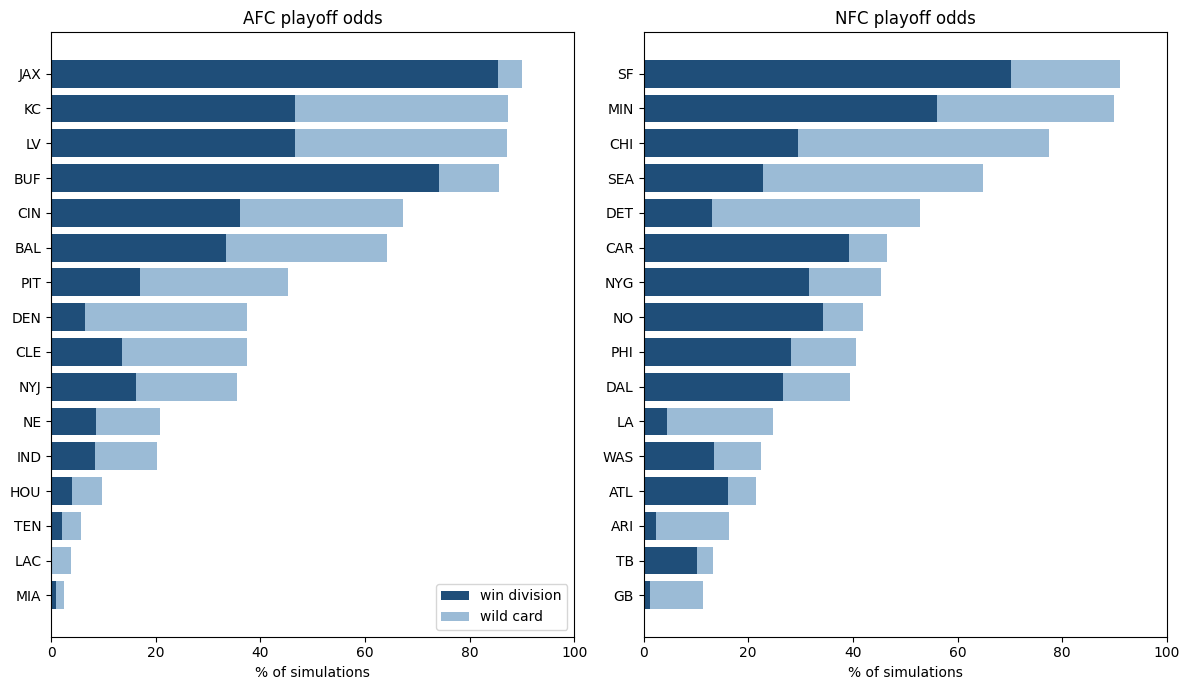

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharex=True)
for ax, c in zip(axs, ["AFC", "NFC"]):
    d = odds[odds.conf == c].sort_values("make playoffs")
    ax.barh(d.team, d["win division"] * 100, color="#1f4e79", label="win division")
    ax.barh(d.team, (d["make playoffs"] - d["win division"]) * 100, left=d["win division"] * 100,
            color="#9bbbd6", label="wild card")
    ax.set(title=f"{c} playoff odds", xlabel="% of simulations", xlim=(0, 100))
axs[0].legend(loc="lower right")
plt.tight_layout()
plt.show()